# Sesión 2 — Relaciones (Machine Learning base)
Objetivo

Correlación + regresión + inferencia básica

## NIVEL FUNDAMENTOS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# =========================================
# SESIÓN 2: RELACIONES Y MODELOS
# =========================================

np.random.seed(42)

n = 200

educacion = np.random.randint(6, 20, n)
experiencia = np.random.randint(0, 30, n)

# modelo sintético realista
ingresos = 800 + 200*educacion + 50*experiencia + np.random.normal(0, 500, n)

df = pd.DataFrame({
    "educacion": educacion,
    "experiencia": experiencia,
    "ingresos": ingresos
})

df.head()

,educacion,experiencia,ingresos
0,12,24,4277.305942
1,9,20,3223.131918
2,18,5,4205.242785
3,16,27,4942.094858
4,13,27,4711.449145


In [ ]:
# ===== 1. CORRELACIÓN =====
df.corr()

,educacion,experiencia,ingresos
educacion,1.000000,0.019675,0.763268
experiencia,0.019675,1.000000,0.471691
ingresos,0.763268,0.471691,1.000000


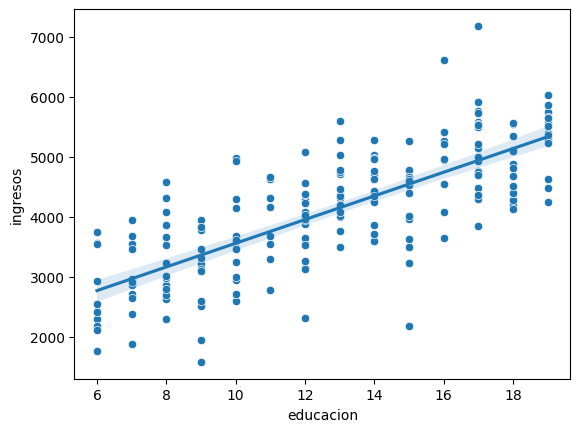

In [ ]:
# ===== 2. SCATTER =====
sns.scatterplot(data=df, x="educacion", y="ingresos")
sns.regplot(data=df, x="educacion", y="ingresos", scatter=False)
plt.show()

In [ ]:
# ===== 3. REGRESIÓN =====
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["educacion"], df["ingresos"]
)

print("Pendiente:", slope)
print("Intercepto:", intercept)
print("R²:", r_value**2)
print("p-valor:", p_value)

Pendiente: 196.99211054799483
Intercepto: 1591.484151273933
R²: 0.582578276759036
p-valor: 2.021944599938436e-39


In [ ]:
# ===== 4. INTERPRETACIÓN =====
# Cada año de educación aumenta ingresos en:
print(f"Aumento por año: {slope:.2f}")

Aumento por año: 196.99


In [ ]:
# ===== 5. t-test =====
grupo1 = df[df["educacion"] > 12]["ingresos"]
grupo2 = df[df["educacion"] <= 12]["ingresos"]

t_stat, p = stats.ttest_ind(grupo1, grupo2)

print("p-valor:", p)

p-valor: 1.1376306065890579e-29


In [ ]:
# ===== EJERCICIO =====
# 1. Analizar experiencia vs ingresos
# 2. Crear otra regresión
# 3. Interpretar resultados

## NIVEL BÁSICO

In [ ]:
# =========================================
# COMPARACIÓN DE MODELOS (BUENO vs MALO)
# =========================================

# ===== MODELO 1: RELACIÓN CLARA =====
n = 200
educacion = np.random.randint(6, 20, n)

ingresos = 1000 + 250*educacion + np.random.normal(0, 200, n)
#Y = 1000+ 250*X + e

df1 = pd.DataFrame({
    "educacion": educacion,
    "ingresos": ingresos
})

slope, intercept, r, p, _ = stats.linregress(df1["educacion"], df1["ingresos"])

print("R²:", r**2)
print("p-valor:", p)

R²: 0.9636161799610329
p-valor: 1.9540979103367882e-144


Modelo ideal:
- Relación fuerte
- Bajo ruido
- Fácil de detectar

Esto rara vez ocurre en ciencias sociales reales

In [ ]:
# ===== MODELO 2: CON RUIDO =====
ingresos = 1000 + 250*educacion + np.random.normal(0, 1000, n)
#Y = 1000+ 250*X + e

df2 = pd.DataFrame({
    "educacion": educacion,
    "ingresos": ingresos
})

slope, intercept, r, p, _ = stats.linregress(df2["educacion"], df2["ingresos"])

print("R²:", r**2)

R²: 0.5379939354083347


Fenómeno social:
- Relación existe
- Pero es débil (ruido alto)

Insight:
R² bajo NO significa que no haya relación

In [ ]:
# ===== MODELO 3: VARIABLE OCULTA =====
habilidad = np.random.normal(0, 1, n)

ingresos = (
    1000
    + 150*educacion
    + 400*habilidad
    + np.random.normal(0, 500, n)
)

df3 = pd.DataFrame({
    "educacion": educacion,
    "ingresos": ingresos
})

slope, intercept, r, p, _ = stats.linregress(df3["educacion"], df3["ingresos"])

print("R²:", r**2)

R²: 0.4411345780230785


Problema clásico:
- Falta variable clave (habilidad)
- Modelo subestima o distorsiona efecto

En sociales esto es la norma, no la excepción

In [ ]:
# ===== MODELO 4: PROXY DEFECTUOSO =====
# "bienestar" medido solo como ingresos

bienestar_real = (
    ingresos
    + np.random.normal(0, 500, n)
)

# usamos SOLO ingresos como proxy
df4 = pd.DataFrame({
    "ingresos": ingresos,
    "bienestar_real": bienestar_real
})

slope, intercept, r, p, _ = stats.linregress(df4["ingresos"], df4["bienestar_real"])

print("R²:", r**2)

R²: 0.7737726826616208


Antropología:
- "Ingresos" ≠ bienestar real
- Ignora redes sociales, cultura, informalidad

Insight:
El problema no es el modelo, es la variable

In [ ]:
# ===== MODELO 5: SESGO (SIMULANDO LIMA) =====
region = np.random.choice(["urbano", "rural"], size=n, p=[0.7, 0.3])

voto = (
    (educacion > 12).astype(int)
    + (region == "urbano").astype(int)
    + np.random.normal(0, 0.5, n)
)

df5 = pd.DataFrame({
    "educacion": educacion,
    "region": region,
    "voto": voto
})

# Filtramos (sesgo)
df5_biased = df5[df5["region"] == "urbano"]

print("Original:", len(df5))
print("Sesgado:", len(df5_biased))

Original: 200
Sesgado: 144


Ciencia política:
- Muestra sesgada (urbana)
- Modelo aprende patrón incorrecto

Similar a encuestas electorales mal diseñadas

In [ ]:
# ===== MODELO 6: ALTA CORRELACIÓN ESPURIA =====
helados = np.random.normal(30, 10, n)
ahogamientos = helados + np.random.normal(0, 5, n)

df6 = pd.DataFrame({
    "helados": helados,
    "ahogamientos": ahogamientos
})

print(df6.corr())

               helados  ahogamientos
helados       1.000000      0.889024
ahogamientos  0.889024      1.000000


Correlación alta ≠ causalidad

Variable oculta:
temperatura

Insight:
ML puede aprender relaciones incorrectas muy bien

**COMPARACIÓN FINAL**

- Modelo 1: perfecto (irreal)
- Modelo 2: ruido (realista)
- Modelo 3: variable oculta (problema clásico)
- Modelo 4: mala definición (antropología)
- Modelo 5: sesgo de muestra (política)
- Modelo 6: correlación espuria (error conceptual)

CONCLUSIÓN:
No basta con saber modelar, hay que saber cuestionar el modelo.

### NIVEL INTERMEDIO

In [ ]:
# =========================================
# SESIÓN 2 - NIVEL INTERMEDIO
# =========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os

# ===== CARGAR DATA =====
import kagglehub

path = kagglehub.dataset_download("asifxzaman/university-students-performance-and-study-habits2026")

files = os.listdir(path)
print(files)

df = pd.read_csv(os.path.join(path, files[0]))

df.head()

Using Colab cache for faster access to the 'university-students-performance-and-study-habits2026' dataset.
['global_university_students_performance_habits_10000.csv']


,student_id,age,gender,country,major,university_year,GPA,study_hours_per_day,class_attendance_percent,sleep_hours,...,internet_quality,mental_stress_level,AI_tool_usage_hours,favorite_AI_tool,note_taking_method,exam_preparation_days,coffee_consumption_per_day,extracurricular_hours_per_week,final_exam_score,assignment_score
0,S00001,23,Female,Germany,Law,4,3.81,4.2,96,6.2,...,Average,4.8,1.5,Claude,Digital,15,3,7.6,100,100
1,S00002,26,Female,USA,Economics,2,3.46,3.3,94,6.6,...,Average,3.9,2.3,Gemini,Mixed,11,3,5.2,100,83
2,S00003,18,Female,Canada,Medicine,3,4.00,4.5,100,6.3,...,Average,4.8,0.0,NaN,Mixed,12,3,4.6,100,100
3,S00004,20,Male,Australia,Physics,4,3.77,5.8,97,7.1,...,Good,5.9,2.9,Gemini,Mixed,11,1,4.0,100,98
4,S00005,28,Female,Australia,Medicine,2,4.00,3.1,96,8.4,...,Good,3.1,1.5,ChatGPT,Handwritten,15,4,1.4,100,94


In [ ]:
# ===== VARIABLES CLAVE =====
cols = [
    "GPA",
    "study_hours_per_day",
    "sleep_hours",
    "social_media_hours",
    "mental_stress_level"
]

df = df[cols]

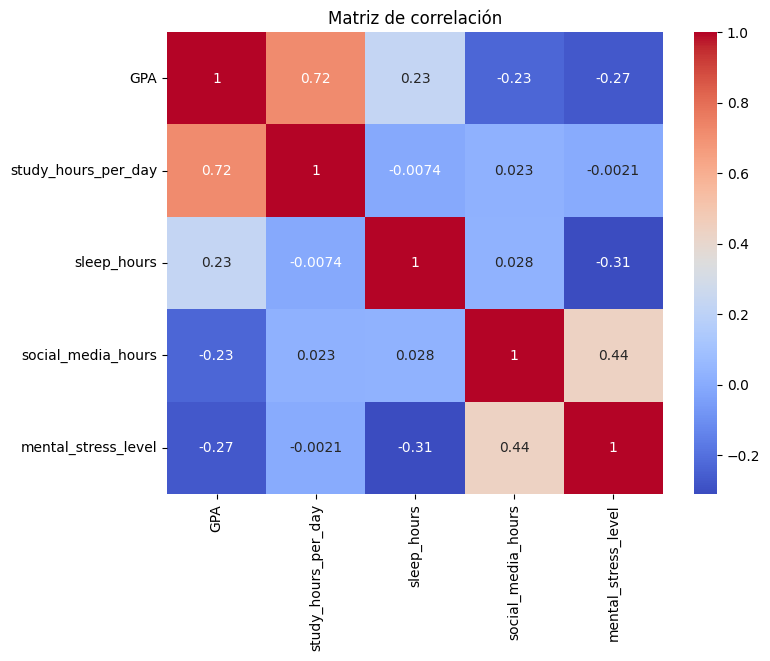

In [ ]:
# ===== 1. CORRELACIÓN =====
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

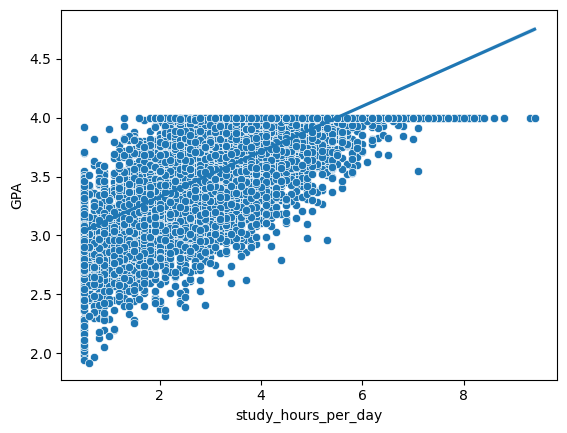

In [ ]:
# ===== 2. RELACIÓN CLAVE =====
sns.scatterplot(data=df, x="study_hours_per_day", y="GPA")
sns.regplot(data=df, x="study_hours_per_day", y="GPA", scatter=False)
plt.show()

In [ ]:
# ===== 3. REGRESIÓN =====
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["study_hours_per_day"], df["GPA"]
)

print("Pendiente:", slope)
print("R²:", r_value**2)
print("p-valor:", p_value)

Pendiente: 0.19219504157626874
R²: 0.5143495824893596
p-valor: 0.0


In [ ]:
# ===== 4. HIPÓTESIS =====
# ¿Dormir más mejora GPA?

grupo1 = df[df["sleep_hours"] >= 7]["GPA"]
grupo2 = df[df["sleep_hours"] < 7]["GPA"]

t_stat, p = stats.ttest_ind(grupo1, grupo2)

print("\nT-test sueño:")
print("p-valor:", p)


T-test sueño:
p-valor: 2.045138385185349e-86


In [ ]:
# ===== 5. INTERPRETACIÓN =====
if p < 0.05:
    print("Diferencia significativa")
else:
    print("No concluyente")

Diferencia significativa


In [ ]:
# ===== EJERCICIO =====
# 1. Analizar stress vs GPA
# 2. Analizar social media vs GPA
# 3. ¿Qué variable parece más importante?

## NIVEL AVANZADO

In [ ]:
# =========================================
# SESIÓN 2 - NIVEL AVANZADO (ML)
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score

# ===== CARGAR DATA =====
import kagglehub

#path = kagglehub.dataset_download("asifxzaman/university-students-performance-and-study-habits2026")

files = os.listdir(path)
df = pd.read_csv(os.path.join(path, files[0]))

In [ ]:
# ===== VARIABLES =====
features = [
    "study_hours_per_day",
    "sleep_hours",
    "social_media_hours",
    "mental_stress_level",
    "class_attendance_percent"
]

target = "GPA"

X = df[features]
y = df[target]

In [ ]:
# ===== TRAIN TEST SPLIT =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ===== REGRESIÓN MÚLTIPLE =====
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 0.04513836459345582


In [ ]:
# ===== IMPORTANCIA DE VARIABLES =====
coef_df = pd.DataFrame({
    "Variable": features,
    "Coeficiente": model.coef_
})

print("\nImpacto de variables:")
print(coef_df.sort_values(by="Coeficiente", ascending=False))


Impacto de variables:
                   Variable  Coeficiente
0       study_hours_per_day     0.128869
1               sleep_hours     0.050227
4  class_attendance_percent     0.013711
2        social_media_hours    -0.035409
3       mental_stress_level    -0.036351


In [ ]:
# ===== CLASIFICACIÓN =====
# Crear variable: alto rendimiento (GPA > 3.5)

df["alto_rendimiento"] = (df["GPA"] > 3.5).astype(int)

X = df[features]
y = df["alto_rendimiento"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("\nAccuracy clasificación:", accuracy_score(y_test, y_pred))


Accuracy clasificación: 0.8635


Interpretación:
- Regresión: predice GPA
- Clasificación: predice si estudiante tiene alto rendimiento

In [ ]:
# ===== EJERCICIO =====
# 1. Cambiar variable objetivo (ej: final_exam_score)
# 2. Probar otro modelo
# 3. ¿Qué variables explican mejor el rendimiento?